## This code fits a pruned regression tree to latestPrice and logLatestPrice

### WARNING: These models can take a long time to run

In [2]:
# I didn't want to look this up as I adapted my homework code to this problem, so chatGPT made this list for me 

# === Core ===
import numpy as np
import pandas as pd

# === Visualization ===
import matplotlib.pyplot as plt

# === Model Selection & Evaluation ===
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.metrics import mean_squared_error

# === Tree-Based Model ===
from sklearn.tree import DecisionTreeRegressor, plot_tree

# === Utility ===
import warnings
warnings.filterwarnings("ignore")



In [11]:
housing_binary_prune = pd.read_csv('housing_data_numeric_NLP.csv') # your transformed file name here
housing_binary_prune['logLatestPrice'] = np.log(housing_binary_prune['latestPrice'])
housing_binary_prune

,latitude,longitude,propertyTaxRate,garageSpaces,hasAssociation,hasGarage,hasSpa,hasView,latestPrice,numOfPhotos,...,zipcode78756,zipcode78757,zipcode78758,zipcode78759,log_lotSizeSqFt,log_livingAreaSqFt,log_avgSchoolSize,yearsOld_sq,avgSchoolRating_sq,logLatestPrice
0,30.486408,-97.794724,2.21,0,True,False,False,False,687.850,40,...,0,0,0,0,9.275472,8.426174,7.138867,64,58.777778,6.533571
1,30.494375,-97.796516,2.21,2,True,True,False,True,409.000,31,...,0,0,0,0,9.111735,8.081475,7.301148,225,69.444444,6.013715
2,30.255707,-97.576958,1.98,2,False,True,False,False,199.000,21,...,0,0,0,0,8.915835,7.321189,7.299121,256,7.111111,5.293305
3,30.495638,-97.797874,2.21,0,True,False,False,False,400.000,20,...,0,0,0,0,8.944681,7.709308,7.301148,196,69.444444,5.991465
4,30.233154,-97.587318,1.98,2,False,True,False,False,240.000,10,...,0,0,0,0,8.553332,7.336286,7.284821,529,9.000000,5.480639
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6779,30.329531,-97.738258,1.98,4,False,True,False,False,647.877,28,...,1,0,0,0,9.573302,7.711997,7.081709,324,49.000000,6.473701
6780,30.326372,-97.734268,1.98,1,False,True,False,False,445.000,28,...,1,0,0,0,8.849371,7.181592,7.081709,5329,49.000000,6.098074
6781,30.327656,-97.734779,1.98,1,False,True,False,False,400.000,22,...,1,0,0,0,9.212239,7.123673,7.081709,5041,49.000000,5.991465
6782,30.240223,-97.772835,1.98,2,True,True,True,True,550.000,32,...,0,0,0,0,7.799753,7.543803,7.112327,36,44.444444,6.309918


In [12]:
#from the sklearn documentation
housing_train, housing_test = train_test_split(housing_binary_prune,test_size = .3, train_size = .7, random_state = 123, shuffle = True)


## Code for latestPrice

Initial Deep Tree In-Sample MSE: $0.00


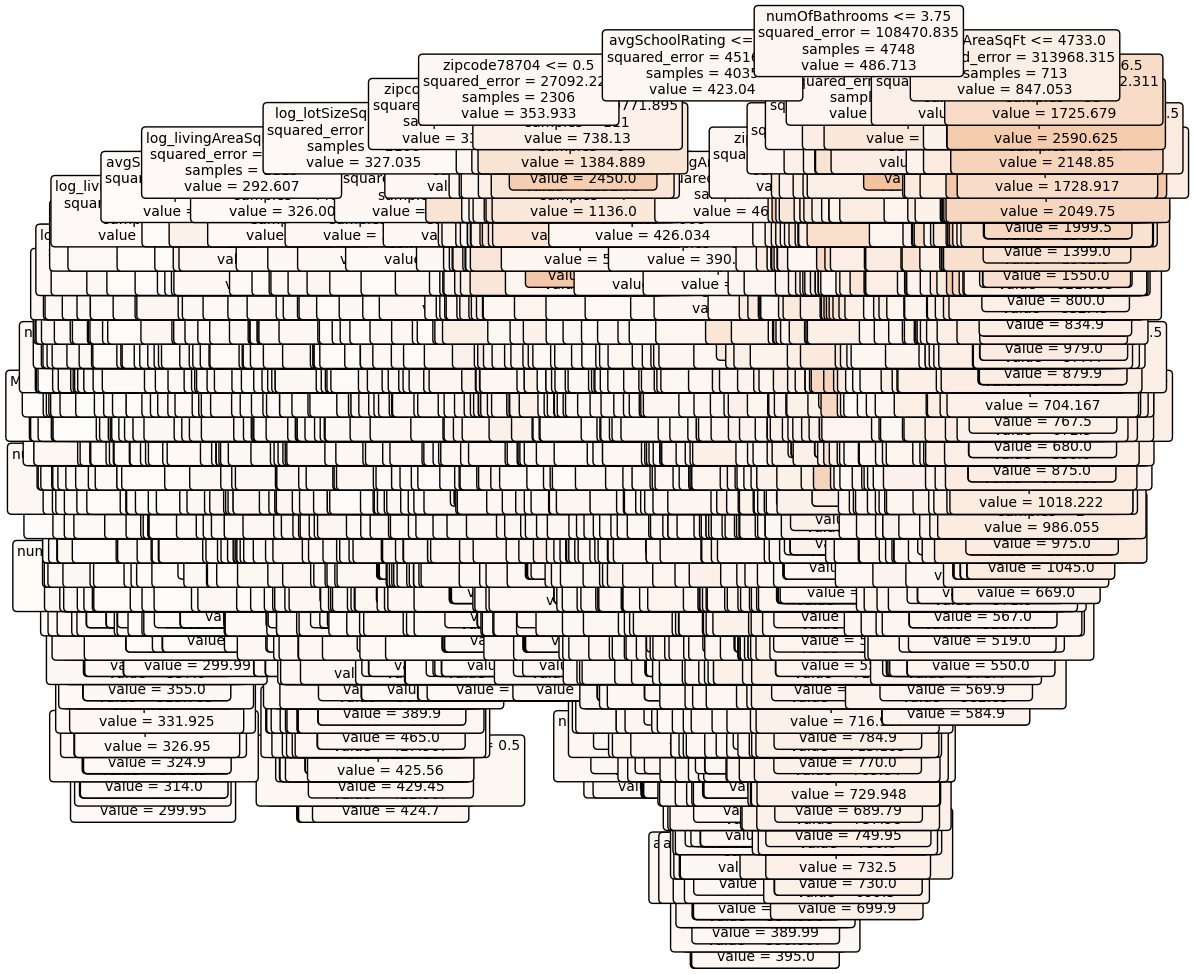

In [14]:
predictors = housing_train.drop(columns = ['latestPrice','logLatestPrice'])
target = housing_train['latestPrice']

X_train = predictors
y_train = target

# I took this from the scikitlearn documentation online and the book.
# I let it run deep for the first go so it could be pruned back in the next step.
# I used the same big tree parameters as in class:
# a node must have two data-points
# very small manual complexity penalty
regr_base = DecisionTreeRegressor(ccp_alpha = .0001, min_samples_split = 2, random_state = 123)
regr_base.fit(X_train, y_train)

# plotting from the book with some LLM help for readability
fig, ax = plt.subplots(figsize=(12, 12))  
plot_tree(regr_base, feature_names=predictors.columns, filled=True, rounded=True, fontsize=10, ax=ax)

# have to predict to get MSE
y_train_base = regr_base.predict(X_train)

# then you have to exponentiate when doign the MSE calculation
mse_base = mean_squared_error(y_train, y_train_base)
print(f'Initial Deep Tree In-Sample MSE: ${mse_base:,.02f}')

## obviously this is absurd, so we're going to prune it:

In [ ]:
# code adapted from the book

# the penalizing feature
ccp_path = regr_base.cost_complexity_pruning_path(X_train, y_train)

# setting up the cross validation
kfold = KFold(5, shuffle = True, random_state = 123)

# let's tune everything with cross validation and see how long this takes...
param_grid = {
    'ccp_alpha': ccp_path.ccp_alphas,
    'min_samples_split': [2, 5, 10],
    'max_depth': [None, 10, 20, 30]
}


grid = GridSearchCV(estimator = regr_base, # starts with the deep tree
                    param_grid = param_grid, # cross validation grid search
                        refit = True, # does the retrain for us on the full set
                        cv = kfold, # cross validation method (set up earlier)
                        scoring = 'neg_mean_squared_error', # scoring
                   n_jobs = -1) # use multiple cores 

G = grid.fit(X_train, y_train)

best_ = grid.best_estimator_ # fully cross validated and trained model lives here

y_pred_best = best_.predict(X_train)
mse_best = mean_squared_error(y_train, y_pred_best)

fig, ax = plt.subplots(figsize = (12,12))
plot_tree(G.best_estimator_, feature_names = predictors.columns, filled = True, rounded = True, fontsize = 10, ax = ax)

print(f'Pruned Tree In Sample MSE: ${mse_best:,.02f}')

In [ ]:
# Final evaluation on test set
X_test = housing_test.drop(columns=['latestPrice', 'logLatestPrice'])  
y_test = housing_test['latestPrice']                                   


y_test_pred = best_.predict(X_test)
mse_test = mean_squared_error(y_test, y_test_pred)
print(f'Out of Sample Test MSE: ${mse_test:,.02f}')

## Code for logLatestPrice

In [ ]:
# I didn't feel like making all the little changes to switch two words, so chatGPT did it for me

In [ ]:
# Setup for logLatestPrice as the new target
predictors = housing_train.drop(columns = ['latestPrice', 'logLatestPrice'])
target = housing_train['logLatestPrice']

X_train = predictors
y_train = target

# this is to set up the deep base tree
regr_base = DecisionTreeRegressor(ccp_alpha = .0001, min_samples_split = 2, random_state = 123)
regr_base.fit(X_train, y_train)

# plotting from the book with some LLM help for readability
fig, ax = plt.subplots(figsize=(12, 12))  
plot_tree(regr_base, feature_names=predictors.columns, filled=True, rounded=True, fontsize=10, ax=ax)

# have to predict to get MSE
y_train_base = regr_base.predict(X_train)
mse_base = mean_squared_error(np.exp(y_train), np.exp(y_train_base))
print(f'Initial Deep Tree In-Sample MSE: {mse_base:.4f}')


## Obviously this is absurd, so we're going to prune it:

In [ ]:
# Get pruning path
ccp_path = regr_base.cost_complexity_pruning_path(X_train, y_train)

# Cross-validation setup
kfold = KFold(5, shuffle=True, random_state=123)

# Hyperparameter grid
param_grid = {
    'ccp_alpha': ccp_path.ccp_alphas,
    'min_samples_split': [2, 5, 10],
    'max_depth': [None, 10, 20, 30]
}

# Grid search with CV
grid = GridSearchCV(
    estimator=regr_base,
    param_grid=param_grid,
    refit=True,
    cv=kfold,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

G = grid.fit(X_train, y_train)

best_ = grid.best_estimator_

# In-sample predictions and MSE
y_pred_best = best_.predict(X_train)
mse_best = mean_squared_error(np.exp(y_train), np.exp(y_pred_best))

fig, ax = plt.subplots(figsize=(12, 12))
plot_tree(best_, feature_names=predictors.columns, filled=True, rounded=True, fontsize=10, ax=ax)

print(f'Pruned Tree In-Sample MSE: {mse_best:.4f}')


In [ ]:
# Final evaluation on test set using logLatestPrice
X_test = housing_test.drop(columns=['latestPrice', 'logLatestPrice'])  
y_test = housing_test['logLatestPrice']                                 

y_test_pred = best_.predict(X_test)
mse_test = mean_squared_error(np.exp(y_test), np.exp(y_test_pred))
print(f'Out of Sample Test MSE: {mse_test:.4f}')
